# PARTIE B:  Machine Learning — Prediction d'un accouchement assisté par un persnonnel qualifié en RDC


## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier

# Sélection et évaluation
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, cross_val_score
)
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import (
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

print('Bibliothèques importées avec succès.')

Bibliothèques importées avec succès.


## 2. Chargement et préparation des données

In [2]:
# Chargement du fichier exporté par le notebook d'analyse statistique
data = pd.read_csv('CDIR81FL.csv', sep=';')
print(f'Dimensions initiales : {data.shape}')
data.head()

Dimensions initiales : (10362, 21)


,caseid,v005,v021,v013,v024,v025,v106,v130,v190,v717,...,v701,v157,v158,v159,v743a,v743b,v743d,SBA,cpn_visites,poids_final
0,1 8 2,203638,1,7,5,2,0,7,1,4,...,1,0,0,0,2,2,2,1,4.0,0.203638
1,1 24 2,203638,1,2,5,2,1,9,2,0,...,2,0,0,0,1,4,1,1,3.0,0.203638
2,1 49 2,203638,1,6,5,2,0,1,1,4,...,2,0,1,0,2,2,2,0,1.0,0.203638
3,1 56 3,203638,1,2,5,2,2,4,1,4,...,2,0,0,0,1,1,1,1,5.0,0.203638
4,1 80 2,203638,1,3,5,2,2,2,2,0,...,2,0,0,0,1,4,1,0,3.0,0.203638


### 2.1 Catégorisation de la parité (standard Sanni Yaya)

In [3]:
def categoriser_parite(x):
    """Regroupe la parité en 3 classes : référence = 1-2 enfants."""
    if pd.isna(x): return '1-2'          # on rattache les rares NaN à la référence
    if x <= 2:     return '1-2'
    elif x <= 4:   return '3-4'
    else:          return '5+'

data['parite'] = data['v201'].apply(categoriser_parite)
data['parite'] = pd.Categorical(data['parite'],
                                categories=['1-2', '3-4', '5+'],
                                ordered=False)
data = data.drop(columns=['v201'])        # v201 numérique n'est plus nécessaire
print(data['parite'].value_counts())

parite
5+     4119
1-2    3196
3-4    3047
Name: count, dtype: int64


### 2.2 Catégorisation des consultations prénatales (CPN)

In [4]:
def categoriser_cpn(x):
    """Effet de seuil OMS : 0 / 1-3 / 4+ visites."""
    if pd.isna(x) or x == 0: return '0'
    elif 1 <= x <= 3:         return '1-3'
    else:                     return '4+'

data['cpn_cat'] = data['cpn_visites'].apply(categoriser_cpn)
data['cpn_cat'] = pd.Categorical(data['cpn_cat'],
                                 categories=['0', '1-3', '4+'],
                                 ordered=False)
data = data.drop(columns=['cpn_visites'])  # variable numérique brute remplacée
print(data['cpn_cat'].value_counts())

cpn_cat
1-3    4251
4+     4016
0      2095
Name: count, dtype: int64


### 2.3 Typage des variables catégorielles

In [5]:
vars_cat = [
    'v013', 'v024', 'v025', 'v106', 'v130', 'v190',
    'v717', 'v701', 'v157', 'v158', 'v159',
    'v743a', 'v743b', 'v743d',
    'parite', 'cpn_cat'
]
for col in vars_cat:
    data[col] = data[col].astype('category')

print('Types :')
print(data[vars_cat].dtypes)

Types :
v013       category
v024       category
v025       category
v106       category
v130       category
v190       category
v717       category
v701       category
v157       category
v158       category
v159       category
v743a      category
v743b      category
v743d      category
parite     category
cpn_cat    category
dtype: object


## 3. Division du jeu de données (80 % train / 20 % test)

In [6]:
# Encodage one-hot AVANT le split (acceptable pour des variables nominales)
# drop_first=True évite la multicolinéarité parfaite (dummy trap)
data_dummies = pd.get_dummies(data, columns=vars_cat, drop_first=True)

# Conversion des booléens en entiers 0/1
bool_cols = data_dummies.select_dtypes(include='bool').columns
data_dummies[bool_cols] = data_dummies[bool_cols].astype(int)

print(f'Dimensions après encodage : {data_dummies.shape}')

Dimensions après encodage : (10362, 87)


In [7]:
# Colonnes à exclure des prédicteurs (identifiants + pondération + cible)
exclure   = ['caseid', 'v005', 'v021', 'SBA', 'poids_final']
features  = [c for c in data_dummies.columns if c not in exclure]

X = data_dummies[features]
y = data_dummies['SBA']

# stratify=y garantit la même proportion SBA dans train et test
# (indispensable avec 84 % / 16 % de déséquilibre)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = 42,
    stratify     = y
)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f"Distribution SBA — Train : {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Distribution SBA — Test  : {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train : (8289, 82)  |  Test : (2073, 82)
Distribution SBA — Train : {1: 0.772, 0: 0.228}
Distribution SBA — Test  : {1: 0.772, 0: 0.228}


In [8]:
# Standardisation : fit sur train uniquement → transform sur train et test
# Evite la fuite d'information (data leakage) vers le jeu de test
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Modèles sensibles à l'échelle → données scalées
# Modèles basés sur les arbres   → données brutes (non scalées)
SCALE_NEEDED = {'Logistic Regression', 'SVM', 'KNN'}

def get_X(name, split='train'):
    """Retourne les données correctes selon le modèle et le split."""
    if name in SCALE_NEEDED:
        return X_train_scaled if split == 'train' else X_test_scaled
    return X_train.values if split == 'train' else X_test.values

print('Standardisation terminée.')

Standardisation terminée.


## 4. Entraînement et sélection par GridSearchCV

**Choix du scoring : `roc_auc`**  
Avec un déséquilibre de classes (84 % assisté / 16 % non-assisté), l'`accuracy` est trompeuse  
(un modèle naïf prédisant toujours 1 obtiendrait déjà 84 %).  
L'AUC mesure la capacité discriminante réelle du modèle, indépendamment du seuil de décision.

In [9]:
# Configuration des 6 modèles et de leur grille d'hyperparamètres
models_config = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100], 'max_depth': [10, 20]}
    ),
    'SVM': (
        SVC(probability=True, random_state=42),
        {'C': [1, 10], 'kernel': ['rbf']}
    ),
    'Gradient Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'learning_rate': [0.05, 0.1], 'n_estimators': [100, 200]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'n_neighbors': [5, 10]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {'max_depth': [5, 10]}
    )
}

# Validation croisée interne du GridSearch : stratifiée pour respecter le déséquilibre
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultats_gridsearch = []
best_estimators      = {}

for name, (model, params) in models_config.items():
    print(f'Entraînement de {name}...')

    grid = GridSearchCV(
        estimator  = model,
        param_grid = params,
        cv         = cv_inner,
        scoring    = 'roc_auc',   # métrique adaptée au déséquilibre
        n_jobs     = -1,
        refit      = True         # ré-entraîne sur tout X_train avec les meilleurs params
    )
    grid.fit(get_X(name, 'train'), y_train)

    best_estimators[name] = grid.best_estimator_

    # Évaluation sur le test set (données jamais vues)
    y_pred  = grid.best_estimator_.predict(get_X(name, 'test'))
    y_proba = grid.best_estimator_.predict_proba(get_X(name, 'test'))[:, 1]

    resultats_gridsearch.append({
        'Modèle'          : name,
        'AUC (CV interne)': round(grid.best_score_, 4),
        'AUC (Test)'      : round(roc_auc_score(y_test, y_proba), 4),
        'Accuracy (Test)' : round((y_pred == y_test).mean(), 4),
        'Meilleurs params': grid.best_params_
    })

df_comparaison = (pd.DataFrame(resultats_gridsearch)
                    .sort_values('AUC (CV interne)', ascending=False)
                    .reset_index(drop=True))

print('\nCOMPARAISON DES 6 MODÈLES')
print(df_comparaison[['Modèle', 'AUC (CV interne)', 'AUC (Test)', 'Accuracy (Test)']].to_string(index=False))

Entraînement de Logistic Regression...
Entraînement de Random Forest...
Entraînement de SVM...
Entraînement de Gradient Boosting...
Entraînement de KNN...
Entraînement de Decision Tree...

COMPARAISON DES 6 MODÈLES
             Modèle  AUC (CV interne)  AUC (Test)  Accuracy (Test)
Logistic Regression            0.8422      0.8339           0.8273
  Gradient Boosting            0.8410      0.8324           0.8254
      Random Forest            0.8378      0.8283           0.8114
                SVM            0.8224      0.8204           0.8292
      Decision Tree            0.7934      0.7843           0.8133
                KNN            0.7594      0.7386           0.7612


## 5. Validation croisée finale du meilleur modèle

Le GridSearchCV choisit les hyperparamètres (CV interne).  
Cette étape **évalue la stabilité** du modèle retenu sur l'ensemble d'entraînement  
via une CV externe stratifiée à 5 plis — ce sont deux rôles distincts.

In [10]:
# Identification automatique du meilleur modèle
best_name  = df_comparaison.iloc[0]['Modèle']
best_model = best_estimators[best_name]
X_cv       = get_X(best_name, 'train')

print(f'Meilleur modèle sélectionné : {best_name}')
print(f'Paramètres optimaux         : {df_comparaison.iloc[0]["Meilleurs params"]}')

# Validation croisée externe (5-Fold stratifiée)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_auc = cross_val_score(best_model, X_cv, y_train, cv=cv_outer, scoring='roc_auc',  n_jobs=-1)
cv_acc = cross_val_score(best_model, X_cv, y_train, cv=cv_outer, scoring='accuracy', n_jobs=-1)

print(f'\nRésultats de la validation croisée 5-Fold ({best_name})')
df_cv = pd.DataFrame({
    'Pli'     : [f'Pli {i+1}' for i in range(5)],
    'AUC'     : cv_auc.round(3),
    'Accuracy': cv_acc.round(4)
})
df_cv.loc['MOYENNE'] = ['MOYENNE', cv_auc.mean().round(3), cv_acc.mean().round(4)]
df_cv.loc['ÉCART-TYPE'] = ['ÉCART-TYPE (±)', cv_auc.std().round(3), cv_acc.std().round(4)]
print(df_cv.to_string(index=False))

print(f'\nConclusion : AUC moyen = {cv_auc.mean():.3f} + ou - {cv_auc.std():.3f}')
print(f'             Accuracy moyenne = {cv_acc.mean():.3f}')

Meilleur modèle sélectionné : Logistic Regression
Paramètres optimaux         : {'C': 0.1}

Résultats de la validation croisée 5-Fold (Logistic Regression)
           Pli   AUC  Accuracy
         Pli 1 0.848    0.8239
         Pli 2 0.834    0.8257
         Pli 3 0.833    0.8124
         Pli 4 0.840    0.8233
         Pli 5 0.856    0.8467
       MOYENNE 0.842    0.8264
ÉCART-TYPE (±) 0.009    0.0112

Conclusion : AUC moyen = 0.842 + ou - 0.009
             Accuracy moyenne = 0.826


## 6. Évaluation détaillée du meilleur modèle sur le jeu de test

In [11]:
y_pred_best  = best_model.predict(get_X(best_name, 'test'))
y_proba_best = best_model.predict_proba(get_X(best_name, 'test'))[:, 1]

print(f'Rapport de classification — {best_name}')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Non-Assisté (0)', 'Assisté (1)']
))
print(f'AUC Score : {roc_auc_score(y_test, y_proba_best):.4f}')

Rapport de classification — Logistic Regression
                 precision    recall  f1-score   support

Non-Assisté (0)       0.69      0.43      0.53       472
    Assisté (1)       0.85      0.94      0.89      1601

       accuracy                           0.83      2073
      macro avg       0.77      0.69      0.71      2073
   weighted avg       0.81      0.83      0.81      2073

AUC Score : 0.8339


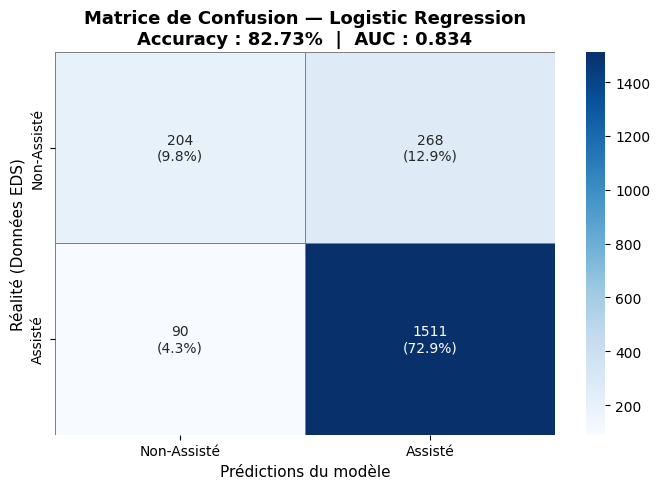

In [12]:
# Matrice de confusion du meilleur modèle
cm = confusion_matrix(y_test, y_pred_best)

# Calcul des métriques
TN, FP, FN, TP = cm.ravel()
total    = TN + FP + FN + TP
accuracy = (TP + TN) / total
auc_val  = roc_auc_score(y_test, y_proba_best)

# Annotations avec pourcentages
cm_pct   = cm / total * 100
annot    = np.array([[f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
                      for j in range(2)] for i in range(2)])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax,
            xticklabels=['Non-Assisté', 'Assisté'],
            yticklabels=['Non-Assisté', 'Assisté'],
            linewidths=0.5, linecolor='grey')
ax.set_title(
    f'Matrice de Confusion — {best_name}\n'
    f'Accuracy : {accuracy:.2%}  |  AUC : {auc_val:.3f}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Prédictions du modèle', fontsize=11)
ax.set_ylabel('Réalité (Données EDS)', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Courbes ROC :Comparaison des 6 modèles

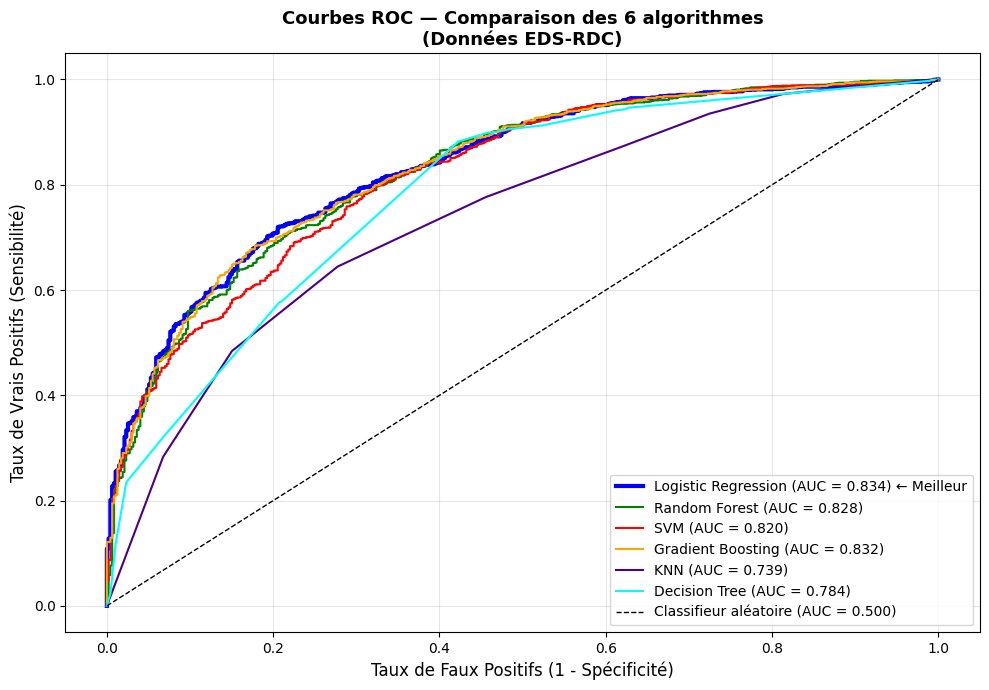

In [13]:
colors = ['blue', 'green', 'red', 'orange', 'indigo', 'cyan']

plt.figure(figsize=(10, 7))

for (name, model), color in zip(best_estimators.items(), colors):
    y_score = model.predict_proba(get_X(name, 'test'))[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc_val  = auc(fpr, tpr)
    # Mettre le meilleur modèle en gras
    lw = 3 if name == best_name else 1.5
    plt.plot(fpr, tpr, color=color, lw=lw,
             label=f'{name} (AUC = {roc_auc_val:.3f})'
                   + (' ← Meilleur' if name == best_name else ''))

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Classifieur aléatoire (AUC = 0.500)')
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)', fontsize=12)
plt.ylabel('Taux de Vrais Positifs (Sensibilité)',   fontsize=12)
plt.title('Courbes ROC — Comparaison des 6 algorithmes\n(Données EDS-RDC)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Matrices de confusion : Les 6 modèles

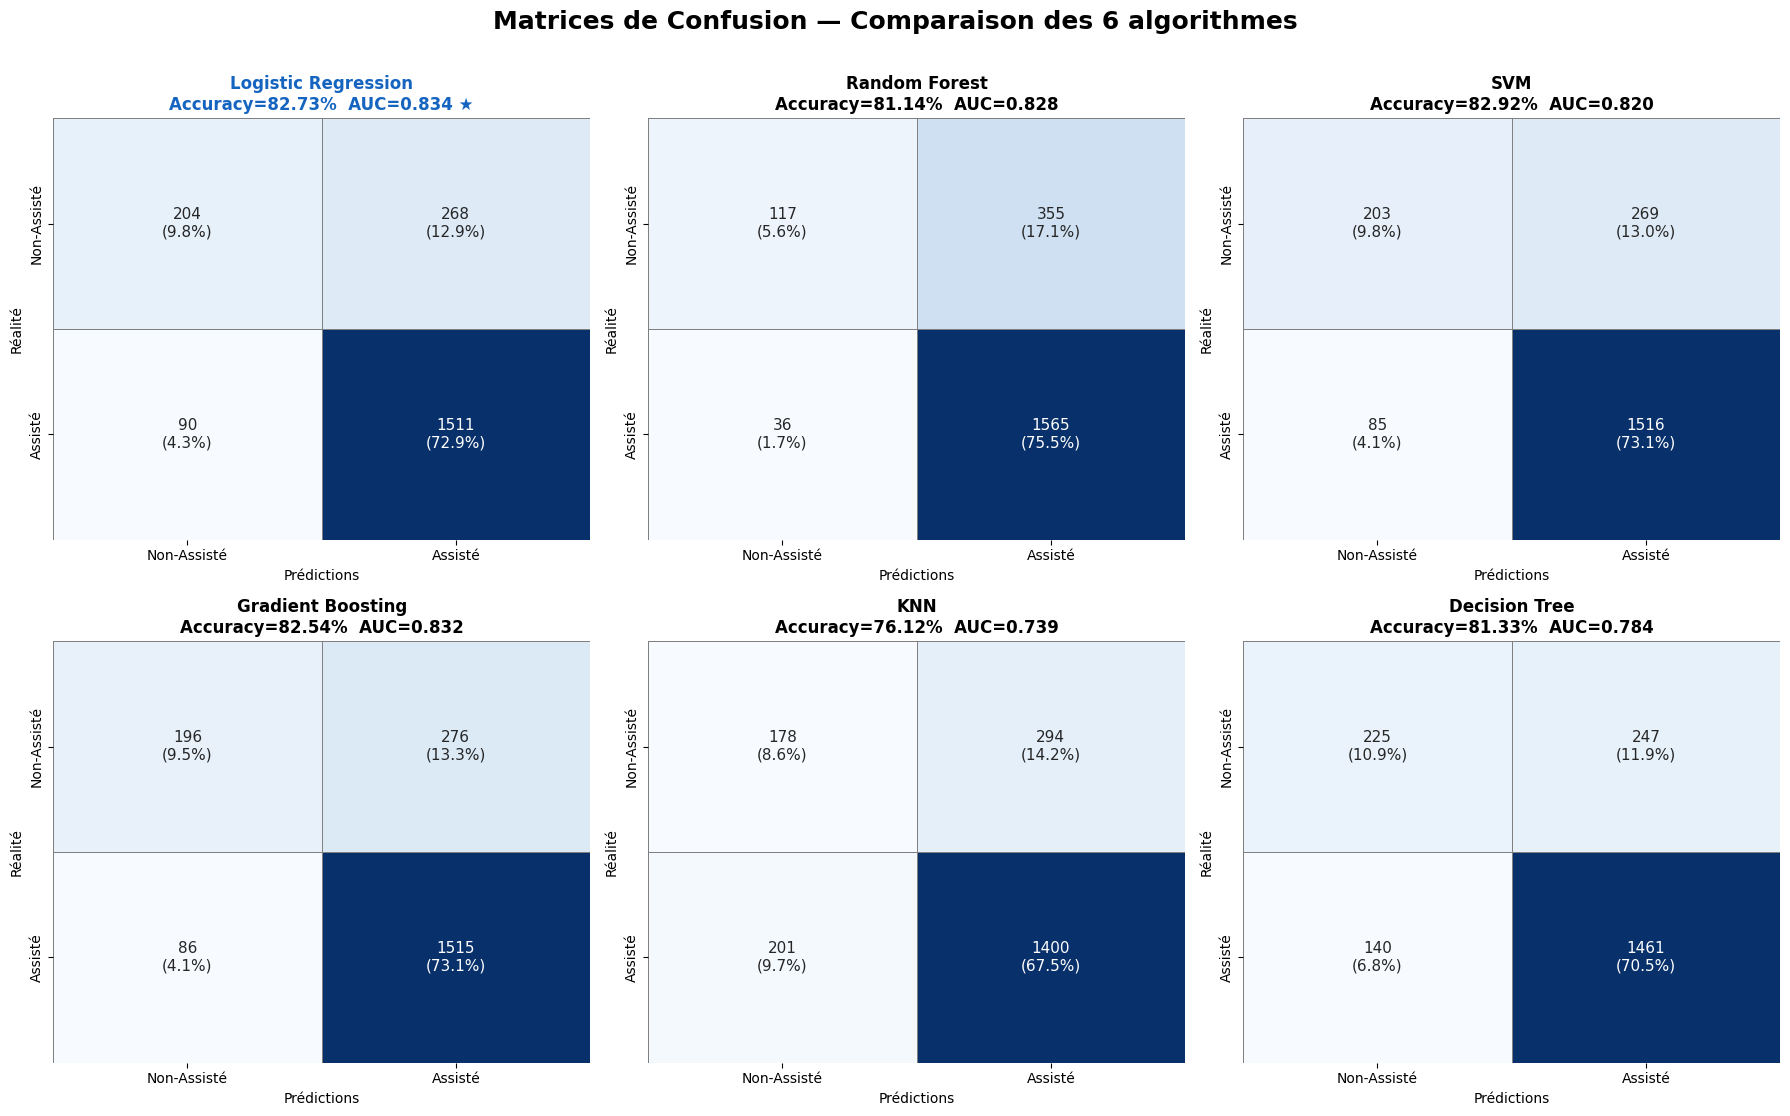

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Matrices de Confusion — Comparaison des 6 algorithmes',
             fontsize=18, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (name, model) in enumerate(best_estimators.items()):
    y_pred_i  = model.predict(get_X(name, 'test'))
    y_proba_i = model.predict_proba(get_X(name, 'test'))[:, 1]

    cm_i     = confusion_matrix(y_test, y_pred_i)
    acc_i    = (y_pred_i == y_test).mean()
    auc_i    = roc_auc_score(y_test, y_proba_i)
    total_i  = cm_i.sum()
    annot_i  = np.array([[f'{cm_i[r,c]}\n({cm_i[r,c]/total_i*100:.1f}%)'
                          for c in range(2)] for r in range(2)])

    sns.heatmap(cm_i, annot=annot_i, fmt='', cmap='Blues', ax=axes[i],
                cbar=False, linewidths=0.5, linecolor='grey',
                xticklabels=['Non-Assisté', 'Assisté'],
                yticklabels=['Non-Assisté', 'Assisté'],
                annot_kws={'size': 11})

    titre_couleur = '#1565C0' if name == best_name else 'black'
    axes[i].set_title(
        f'{name}\nAccuracy={acc_i:.2%}  AUC={auc_i:.3f}'
        + (' ★' if name == best_name else ''),
        fontsize=12, fontweight='bold', color=titre_couleur
    )
    axes[i].set_xlabel('Prédictions', fontsize=10)
    axes[i].set_ylabel('Réalité',     fontsize=10)

plt.tight_layout()
plt.show()

## 9. Importance des variables — Meilleur modèle

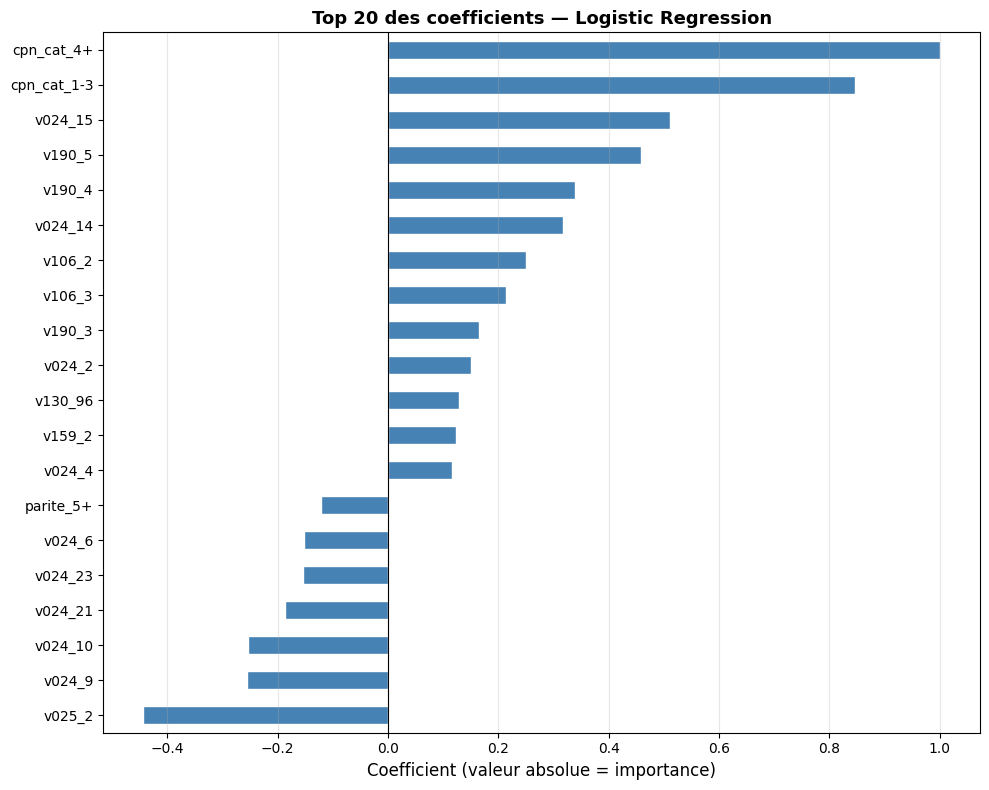

In [15]:
# Cette section fonctionne pour les modèles basés sur les arbres
# (Random Forest, Gradient Boosting, Decision Tree)
# Pour la Régression Logistique, on affiche les coefficients à la place

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices     = np.argsort(importances)[-20:]  # Top 20

    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importances[indices],
             color='steelblue', edgecolor='white')
    plt.yticks(range(len(indices)),
               [list(X_train.columns)[j] for j in indices], fontsize=10)
    plt.xlabel('Importance relative', fontsize=12)
    plt.title(f'Top 20 des variables — {best_name}', fontsize=13, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

elif hasattr(best_model, 'coef_'):
    coef = pd.Series(best_model.coef_[0], index=X_train.columns)
    top20 = coef.abs().nlargest(20).index
    coef[top20].sort_values().plot(kind='barh', color='steelblue',
                                   figsize=(10, 8), edgecolor='white')
    plt.xlabel('Coefficient (valeur absolue = importance)', fontsize=12)
    plt.title(f'Top 20 des coefficients — {best_name}', fontsize=13, fontweight='bold')
    plt.axvline(0, color='black', lw=0.8)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print(f"Le modèle {best_name} ne fournit pas d'importance des variables directement.")

## 10. Tableau de synthèse final

In [16]:
print('=' * 65)
print('       TABLEAU RÉCAPITULATIF — PERFORMANCES SUR LE JEU DE TEST')
print('=' * 65)

synthese = []
for name, model in best_estimators.items():
    y_pred_s  = model.predict(get_X(name, 'test'))
    y_proba_s = model.predict_proba(get_X(name, 'test'))[:, 1]
    cm_s      = confusion_matrix(y_test, y_pred_s)
    TN_s, FP_s, FN_s, TP_s = cm_s.ravel()

    synthese.append({
        'Modèle'          : name,
        'Accuracy'        : round((TP_s + TN_s) / (TP_s + TN_s + FP_s + FN_s), 4),
        'AUC'             : round(roc_auc_score(y_test, y_proba_s), 4),
        'Rappel (SBA=1)'  : round(TP_s / (TP_s + FN_s), 4),
        'Précision (SBA=1)': round(TP_s / (TP_s + FP_s), 4),
        'F1-Score (SBA=1)' : round(2 * TP_s / (2 * TP_s + FP_s + FN_s), 4)
    })

df_synthese = (pd.DataFrame(synthese)
               .sort_values('AUC', ascending=False)
               .reset_index(drop=True))

# Mettre en évidence le meilleur modèle
df_synthese.insert(0, 'Rang', range(1, len(df_synthese) + 1))
print(df_synthese.to_string(index=False))
print('=' * 65)
print(f"\nMEILLEUR MODÈLE : {df_synthese.iloc[0]['Modèle']}")
print(f"  → AUC = {df_synthese.iloc[0]['AUC']}")
print(f"  → Accuracy = {df_synthese.iloc[0]['Accuracy']}")
print(f"  → Rappel sur accouchements assistés = {df_synthese.iloc[0]['Rappel (SBA=1)']}")

       TABLEAU RÉCAPITULATIF — PERFORMANCES SUR LE JEU DE TEST
 Rang              Modèle  Accuracy    AUC  Rappel (SBA=1)  Précision (SBA=1)  F1-Score (SBA=1)
    1 Logistic Regression    0.8273 0.8339          0.9438             0.8494            0.8941
    2   Gradient Boosting    0.8254 0.8324          0.9463             0.8459            0.8933
    3       Random Forest    0.8114 0.8283          0.9775             0.8151            0.8890
    4                 SVM    0.8292 0.8204          0.9469             0.8493            0.8955
    5       Decision Tree    0.8133 0.7843          0.9126             0.8554            0.8830
    6                 KNN    0.7612 0.7386          0.8745             0.8264            0.8498

MEILLEUR MODÈLE : Logistic Regression
  → AUC = 0.8339
  → Accuracy = 0.8273
  → Rappel sur accouchements assistés = 0.9438


In [17]:
# 1. Recherche automatique du modèle et du DataFrame dans l'espace de travail
model_name = None
df_name = None

for var_name, var_value in list(locals().items()):
    if isinstance(var_value, LogisticRegression):
        model_name = var_name
    elif isinstance(var_value, pd.DataFrame) and 'train' in var_name.lower() and var_name != 'df_coefs':
        df_name = var_name

# Si X_train générique n'est pas trouvé, on cherche n'allant au plus simple
if not df_name and 'X_train' in locals():
    df_name = 'X_train'
elif not df_name and 'X' in locals():
    df_name = 'X'

# 2. Affichage des coefficients si trouvés
if model_name and df_name:
    model_obj = locals()[model_name]
    df_obj = locals()[df_name]
    
    print(f" Modèle détecté : '{model_name}'")
    print(f" DataFrame détecté : '{df_name}'\n")
    
    print("=== INTERCEPT (CONSTANTE) ===")
    print(model_obj.intercept_[0])

    print("\n=== COEFFICIENTS DU MODÈLE ===")
    df_coefs = pd.DataFrame({
        'Variable': df_obj.columns,
        'Coefficient': model_obj.coef_[0]
    })
    df_coefs = df_coefs.sort_values(by='Coefficient', ascending=False)
    print(df_coefs.to_string(index=False))
else:
    print(" Impossible de trouver le modèle ou le DataFrame en mémoire.")
    print("Assure-toi d'avoir bien réexécuté toutes les cellules du notebook depuis le début (Menu 'Cell' -> 'Run All').")

 Modèle détecté : 'best_model'
 DataFrame détecté : 'X_train'

=== INTERCEPT (CONSTANTE) ===
1.9463844184315997

=== COEFFICIENTS DU MODÈLE ===
   Variable  Coefficient
 cpn_cat_4+     1.000855
cpn_cat_1-3     0.846851
    v024_15     0.510269
     v190_5     0.457869
     v190_4     0.338118
    v024_14     0.316414
     v106_2     0.250313
     v106_3     0.214249
     v190_3     0.165120
     v024_2     0.150700
    v130_96     0.127871
     v159_2     0.122902
     v024_4     0.116068
    v743d_2     0.111062
    v024_26     0.107271
    v024_16     0.101378
    v024_25     0.099564
     v717_1     0.076934
     v701_2     0.073700
    v743d_4     0.069395
     v701_3     0.068013
     v717_7     0.053821
     v106_1     0.050299
     v190_2     0.043609
    v024_24     0.038509
     v158_2     0.038383
     v130_5     0.037330
    v024_13     0.037073
     v013_5     0.025223
     v717_9     0.025195
    v743a_5     0.024723
     v130_2     0.023735
     v013_6     0.021634
     v